# Medical Insurance Cost Analysis and Prediction System
This Jupyter Notebook contains a clean, production-grade end-to-end data science implementation designed to read a local user-provided CSV dataset (`insurance.csv`). It contains data cleaning, EDA, feature engineering, regression modeling, classification tasks, and a comprehensive Plotly interactive dashboard.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment Configurations & Data Path Allocation
Import necessary analysis libraries and declare your file path directly in the dedicated configuration cell below.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
)

# Set global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### 📂 ENTER YOUR CSV FILE PATH HERE
Modify the `FILE_PATH` string below to point to the file path on your local device or Google Colab drive space (e.g., `'/content/drive/MyDrive/insurance.csv'`).


In [4]:
# ==========================================
# CHANGE THIS PATH TO YOUR OWN CSV FILE:
FILE_PATH = "/content/drive/MyDrive/Python Programs/insurance.csv"
# ==========================================

print(f"Attempting to load data from path: {FILE_PATH}")
df = pd.read_csv(FILE_PATH)

print("\nDataset loaded successfully!")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Rows of the Loaded Data:")
print(df.head())


Attempting to load data from path: /content/drive/MyDrive/Python Programs/insurance.csv

Dataset loaded successfully!
Dataset Shape: 1338 rows, 7 columns

First 5 Rows of the Loaded Data:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## 2. Data Cleaning & Preprocessing
We evaluate the dataset for missing data entries, discard duplicate logs, and review overall structural integrity.


In [5]:
print("--- Missing Values Inventory ---")
print(df.isnull().sum())

# Drop structural row duplicates if any exist
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDropped {initial_rows - len(df)} duplicate records from dataset rows.")

print("\n--- Clean DataFrame Metadata ---")
print(df.info())


--- Missing Values Inventory ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Dropped 1 duplicate records from dataset rows.

--- Clean DataFrame Metadata ---
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None


## 3. Descriptive Statistics Summary Measures
We look at center-tendency values across continuous columns like age, BMI metrics, and pricing distributions.


In [6]:
print("--- Basic Structural Averages ---")
if 'charges' in df.columns:
    print(f"Average Insurance Premium Cost: ${df['charges'].mean():.2f}")
if 'age' in df.columns:
    print(f"Average Customer Age Profile:  {df['age'].mean():.1f} years")
if 'bmi' in df.columns:
    print(f"Average Body Mass Index (BMI): {df['bmi'].mean():.2f} kg/m²")
if 'children' in df.columns:
    print(f"Average Number of Dependents:  {df['children'].mean():.1f}")

print("\n--- Detailed Continuous Feature Metrics Summary ---")
print(df.describe(include='all'))


--- Basic Structural Averages ---
Average Insurance Premium Cost: $13279.12
Average Customer Age Profile:  39.2 years
Average Body Mass Index (BMI): 30.66 kg/m²
Average Number of Dependents:  1.1

--- Detailed Continuous Feature Metrics Summary ---
                age   sex          bmi     children smoker     region  \
count   1337.000000  1337  1337.000000  1337.000000   1337       1337   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   675          NaN          NaN   1063        364   
mean      39.222139   NaN    30.663452     1.095737    NaN        NaN   
std       14.044333   NaN     6.100468     1.205571    NaN        NaN   
min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.290000     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000  

## 4, 5 & 6. Categorical Strata & Influence Relationships
We categorize records across key traits to highlight major cost categories.


In [7]:
# Safe evaluation with cut categories
if 'age' in df.columns and 'bmi' in df.columns:
    df['Age_Group'] = pd.cut(df['age'], bins=[0, 25, 45, 65, 120], labels=['Youth (<=25)', 'Adult (26-45)', 'Senior (46-65)', 'Elderly (>65)'])
    df['BMI_Category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 200], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print("--- Smoker Status Metric vs Charges Average ---")
if 'smoker' in df.columns and 'charges' in df.columns:
    print(df.groupby('smoker')['charges'].mean().map('${:,.2f}'.format))

print("\n--- Gender Status Profile vs Charges Average ---")
if 'sex' in df.columns and 'charges' in df.columns:
    print(df.groupby('sex')['charges'].mean().map('${:,.2f}'.format))

print("\n--- Stratified Age Group vs Charges Average ---")
if 'Age_Group' in df.columns:
    print(df.groupby('Age_Group', observed=False)['charges'].mean().map('${:,.2f}'.format))

print("\n--- Stratified BMI Category vs Charges Average ---")
if 'BMI_Category' in df.columns:
    print(df.groupby('BMI_Category', observed=False)['charges'].mean().map('${:,.2f}'.format))


--- Smoker Status Metric vs Charges Average ---
smoker
no      $8,440.66
yes    $32,050.23
Name: charges, dtype: object

--- Gender Status Profile vs Charges Average ---
sex
female    $12,569.58
male      $13,975.00
Name: charges, dtype: object

--- Stratified Age Group vs Charges Average ---
Age_Group
Youth (<=25)       $9,111.43
Adult (26-45)     $11,983.05
Senior (46-65)    $17,200.43
Elderly (>65)           $nan
Name: charges, dtype: object

--- Stratified BMI Category vs Charges Average ---
BMI_Category
Underweight     $8,657.62
Normal         $10,404.90
Overweight     $11,006.81
Obese          $15,510.92
Name: charges, dtype: object


## 7. Static Exploratory Visualizations Dashboard
We construct standard analytical visualizations using `seaborn` and `matplotlib` to verify spatial distributions.


/tmp/ipykernel_6454/953969937.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='pastel', ax=axes[1,1])


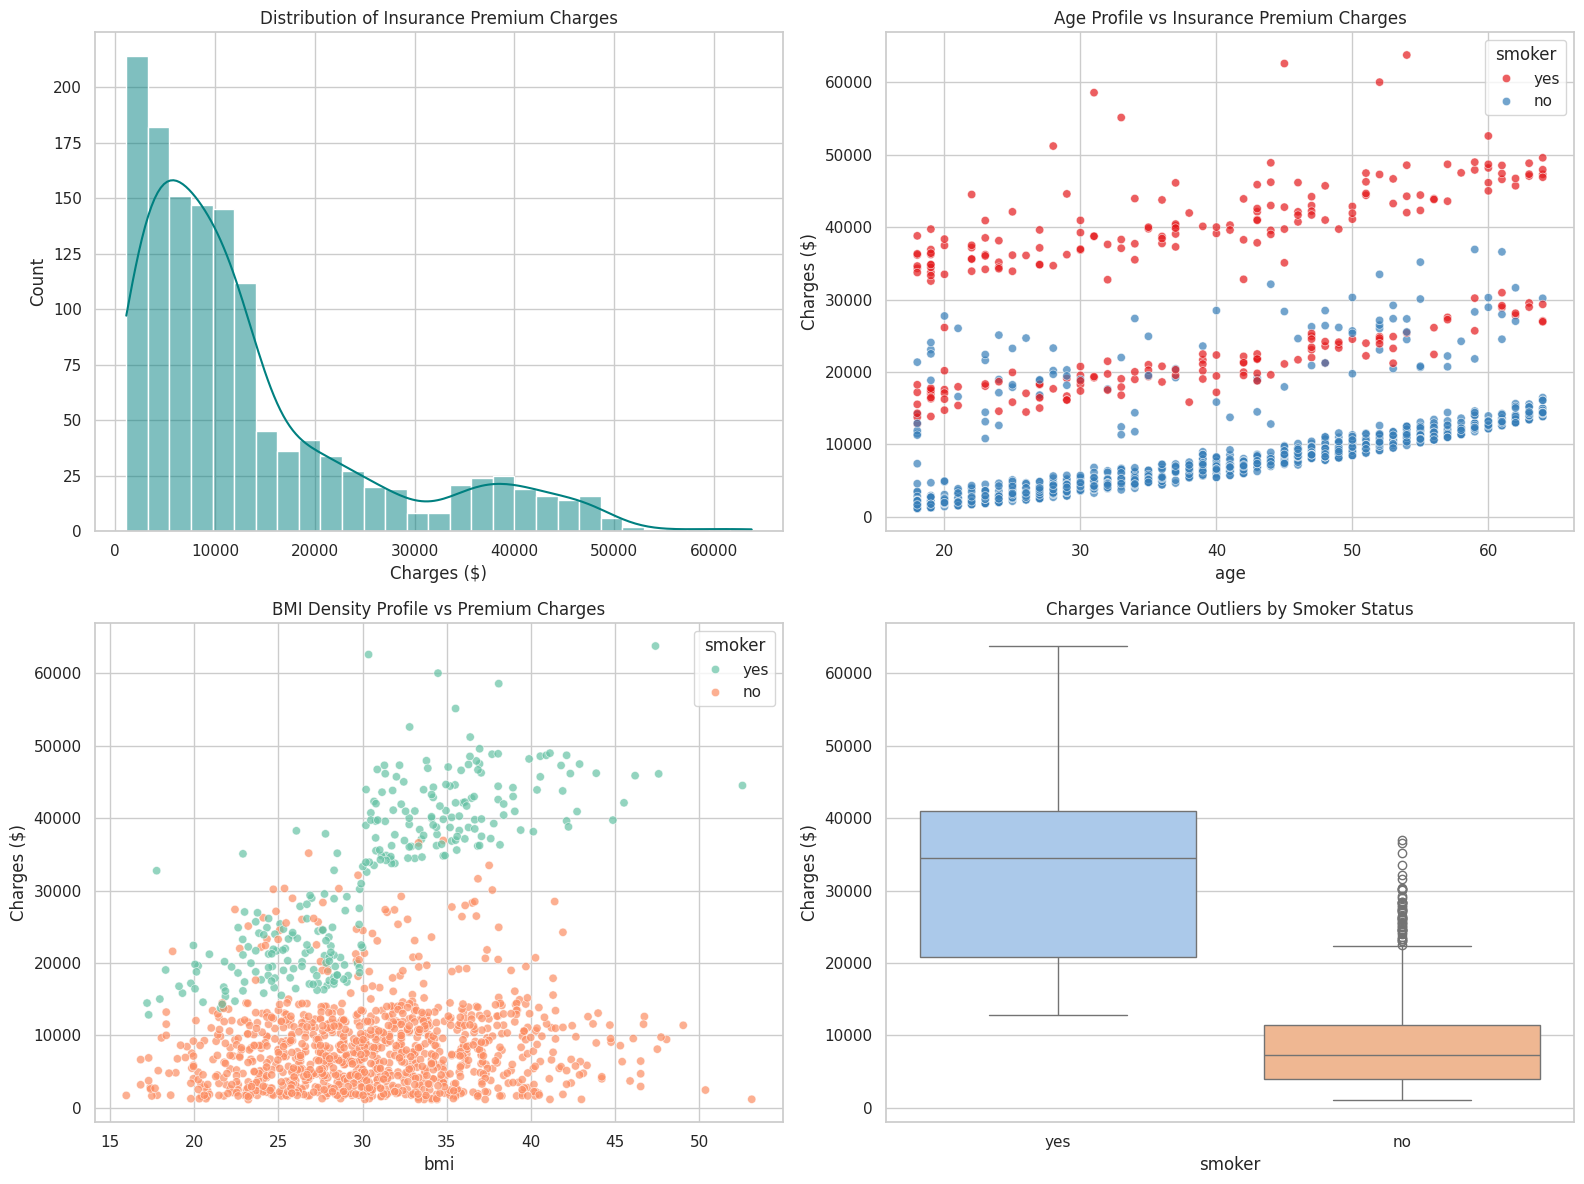

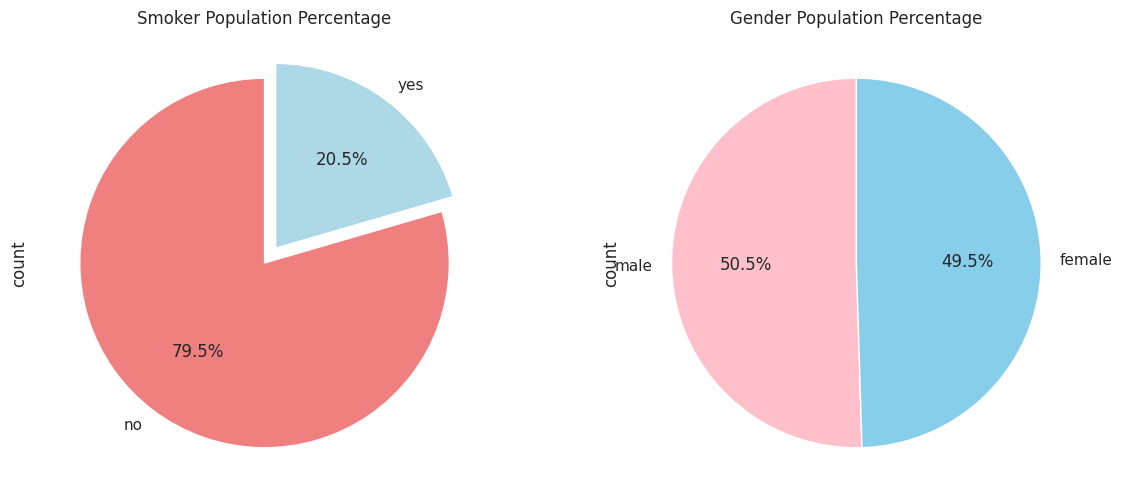

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Premium Cost Distribution Hist
if 'charges' in df.columns:
    sns.histplot(df['charges'], kde=True, color='teal', ax=axes[0,0])
    axes[0,0].set_title('Distribution of Insurance Premium Charges')
    axes[0,0].set_xlabel('Charges ($)')

# 2. Age vs Charges scatter breakdown
if 'age' in df.columns and 'charges' in df.columns:
    sns.scatterplot(data=df, x='age', y='charges', hue='smoker' if 'smoker' in df.columns else None, palette='Set1', alpha=0.7, ax=axes[0,1])
    axes[0,1].set_title('Age Profile vs Insurance Premium Charges')
    axes[0,1].set_ylabel('Charges ($)')

# 3. BMI vs Charges scatter breakdown
if 'bmi' in df.columns and 'charges' in df.columns:
    sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker' if 'smoker' in df.columns else None, palette='Set2', alpha=0.7, ax=axes[1,0])
    axes[1,0].set_title('BMI Density Profile vs Premium Charges')
    axes[1,0].set_ylabel('Charges ($)')

# 4. Boxplots
if 'smoker' in df.columns and 'charges' in df.columns:
    sns.boxplot(data=df, x='smoker', y='charges', palette='pastel', ax=axes[1,1])
    axes[1,1].set_title('Charges Variance Outliers by Smoker Status')
    axes[1,1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# Demographics share pie chart breakdowns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
if 'smoker' in df.columns:
    df['smoker'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightblue'], ax=ax1, explode=(0, 0.1) if len(df['smoker'].unique())==2 else None, startangle=90)
    ax1.set_title('Smoker Population Percentage')
if 'sex' in df.columns:
    df['sex'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink', 'skyblue'], ax=ax2, startangle=90)
    ax2.set_title('Gender Population Percentage')
plt.show()


## 8. Segment Risk Evaluation (Macro Tier Partitioning)
We segment the users into macro tiers based on total claims cost.


In [9]:
if 'charges' in df.columns:
    df['Risk_Tier'] = pd.qcut(df['charges'], q=3, labels=['Low Cost Customer', 'Medium Cost Customer', 'High Cost Customer'])
    print("--- Population Spread Across Dynamic Risk Tiers ---")
    print(df['Risk_Tier'].value_counts())

    print("\n--- Micro Profiling Metrics Grouped by Generated Risk Tier ---")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'charges' in numeric_cols:
        print(df.groupby('Risk_Tier', observed=False)[numeric_cols].mean())


--- Population Spread Across Dynamic Risk Tiers ---
Risk_Tier
Low Cost Customer       446
High Cost Customer      446
Medium Cost Customer    445
Name: count, dtype: int64

--- Micro Profiling Metrics Grouped by Generated Risk Tier ---
                            age        bmi  children       charges
Risk_Tier                                                         
Low Cost Customer     26.520179  30.020774  0.843049   3508.424306
Medium Cost Customer  47.957303  30.957303  1.330337   9426.201073
High Cost Customer    43.208520  31.012937  1.114350  26894.100246


### Label Encoding Phase
Mapping text classification objects directly to clear structural model vectors.


In [10]:
df_encoded = df.copy()
le = LabelEncoder()

categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoded Feature Array Preview Matrix:")
print(df_encoded.head())


Encoded Feature Array Preview Matrix:
   age  sex     bmi  children  smoker  region      charges      Age_Group  \
0   19    0  27.900         0       1       3  16884.92400   Youth (<=25)   
1   18    1  33.770         1       0       2   1725.55230   Youth (<=25)   
2   28    1  33.000         3       0       2   4449.46200  Adult (26-45)   
3   33    1  22.705         0       0       1  21984.47061  Adult (26-45)   
4   32    1  28.880         0       0       1   3866.85520  Adult (26-45)   

  BMI_Category           Risk_Tier  
0   Overweight  High Cost Customer  
1        Obese   Low Cost Customer  
2        Obese   Low Cost Customer  
3       Normal  High Cost Customer  
4   Overweight   Low Cost Customer  


### Multi-Feature Matrix Correlation Analysis


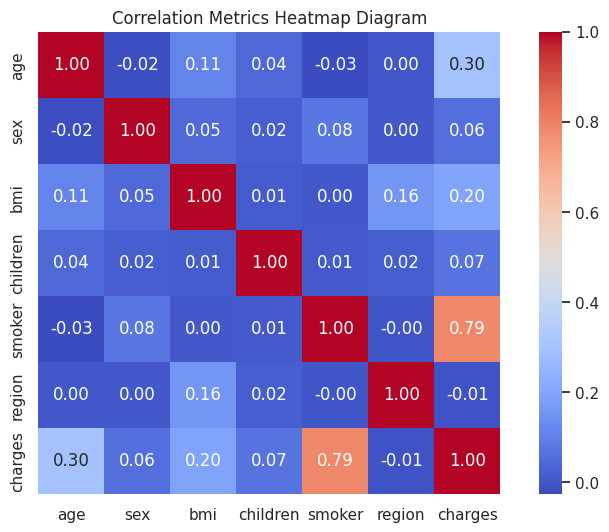

In [11]:
plt.figure(figsize=(10, 6))
target_cols = [c for c in ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'] if c in df_encoded.columns]
sns.heatmap(df_encoded[target_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Metrics Heatmap Diagram")
plt.show()


## 9. Simple Linear Regression Model Experiment
Objective: Forecast premium costs using **only** a single feature variable indicator: `age`.


In [12]:
if 'age' in df_encoded.columns and 'charges' in df_encoded.columns:
    X_simple = df_encoded[['age']]
    y_reg = df_encoded['charges']

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_reg, test_size=0.2, random_state=42)

    lr_simple = LinearRegression()
    lr_simple.fit(X_train_s, y_train_s)

    y_pred_s = lr_simple.predict(X_test_s)

    # Simple LR metric benchmarks
    r2_s = r2_score(y_test_s, y_pred_s)
    mae_s = mean_absolute_error(y_test_s, y_pred_s)
    mse_s = mean_squared_error(y_test_s, y_pred_s)
    rmse_s = np.sqrt(mse_s)

    print("--- Simple Linear Regression Baseline Performance Metrics ---")
    print(f"R² Fit Score: {r2_s:.4f}")
    print(f"MAE Error:     ${mae_s:.2f}")
    print(f"MSE Error:     {mse_s:.2f}")
    print(f"RMSE Error:    ${rmse_s:.2f}")
else:
    print("Required columns ('age', 'charges') are missing from data frame.")


--- Simple Linear Regression Baseline Performance Metrics ---
R² Fit Score: 0.0951
MAE Error:     $9657.79
MSE Error:     166275348.23
RMSE Error:    $12894.78


## 10. Multiple Linear Regression Model Experiment
Objective: Evaluate predictions using an expanded array of inputs (`age`, `bmi`, `children`, `smoker`).


In [13]:
features_m = [c for c in ['age', 'bmi', 'children', 'smoker'] if c in df_encoded.columns]

if len(features_m) > 0 and 'charges' in df_encoded.columns:
    X_multi = df_encoded[features_m]
    y_reg = df_encoded['charges']

    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_reg, test_size=0.2, random_state=42)

    lr_multi = LinearRegression()
    lr_multi.fit(X_train_m, y_train_m)

    y_pred_m = lr_multi.predict(X_test_m)

    # Multi LR metric benchmarks
    r2_m = r2_score(y_test_m, y_pred_m)
    mae_m = mean_absolute_error(y_test_m, y_pred_m)
    mse_m = mean_squared_error(y_test_m, y_pred_m)
    rmse_m = np.sqrt(mse_m)

    print(f"Features utilized for training: {features_m}")
    print("\n--- Multiple Linear Regression Performance Metrics ---")
    print(f"R² Fit Score: {r2_m:.4f}")
    print(f"MAE Error:     ${mae_m:.2f}")
    print(f"MSE Error:     {mse_m:.2f}")
    print(f"RMSE Error:    ${rmse_m:.2f}")
else:
    print("Required columns for multiple regression are missing.")


Features utilized for training: ['age', 'bmi', 'children', 'smoker']

--- Multiple Linear Regression Performance Metrics ---
R² Fit Score: 0.8046
MAE Error:     $4198.59
MSE Error:     35914551.48
RMSE Error:    $5992.88


## 11. Logistic Regression Binary Classifier Deployment
Objective: Predict membership inside `0` (Low Cost) and `1` (High Cost) outcome profiles using a split threshold set at the median target value.


In [14]:
if 'charges' in df_encoded.columns and len(features_m) > 0:
    median_threshold = df_encoded['charges'].median()
    df_encoded['insurance_category'] = (df_encoded['charges'] > median_threshold).astype(int)

    print(f"Median Categorization Cutoff Value: ${median_threshold:.2f}")
    print("Class Value Distribution Balance:")
    print(df_encoded['insurance_category'].value_counts())

    X_clf = df_encoded[features_m]
    y_clf = df_encoded['insurance_category']

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

    # Scale feature dimensions to maximize optimization convergence speeds
    scaler = StandardScaler()
    X_train_c_scaled = scaler.fit_transform(X_train_c)
    X_test_c_scaled = scaler.transform(X_test_c)

    clf = LogisticRegression(random_state=42)
    clf.fit(X_train_c_scaled, y_train_c)

    y_pred_c = clf.predict(X_test_c_scaled)

    acc = accuracy_score(y_test_c, y_pred_c)
    prec = precision_score(y_test_c, y_pred_c)
    rec = recall_score(y_test_c, y_pred_c)
    f1 = f1_score(y_test_c, y_pred_c)
    cm = confusion_matrix(y_test_c, y_pred_c)

    print("\n--- Logistic Regression Metrics Summary Summary ---")
    print(f"Accuracy Score Matrix: {acc:.4f}")
    print(f"Precision Score Ratio: {prec:.4f}")
    print(f"Recall Rate Ratio:     {rec:.4f}")
    print(f"F1 Balanced Index:     {f1:.4f}")
else:
    print("Incomplete properties framework for classification tasks.")


Median Categorization Cutoff Value: $9386.16
Class Value Distribution Balance:
insurance_category
0    669
1    668
Name: count, dtype: int64

--- Logistic Regression Metrics Summary Summary ---
Accuracy Score Matrix: 0.8993
Precision Score Ratio: 0.8905
Recall Rate Ratio:     0.9104
F1 Balanced Index:     0.9004


## 12. Systematic Performance Diagnostics Matrix Summary


--- Detailed Classification Diagnostic Report ---
                    precision    recall  f1-score   support

 Low Cost Category       0.91      0.89      0.90       134
High Cost Category       0.89      0.91      0.90       134

          accuracy                           0.90       268
         macro avg       0.90      0.90      0.90       268
      weighted avg       0.90      0.90      0.90       268



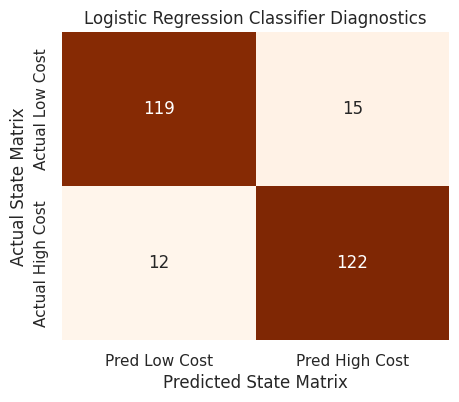


--- Comparative Regression Architecture Dashboard Matrix ---
Evaluation Attribute Criteria  Simple Linear Baseline (Age Only)  Multiple Linear Architecture
         R² Score Coefficient                       9.513001e-02                  8.045531e-01
               MAE Target ($)                       9.657789e+03                  4.198593e+03
           MSE Variance Value                       1.662753e+08                  3.591455e+07
            RMSE Variance ($)                       1.289478e+04                  5.992875e+03


In [15]:
if 'charges' in df_encoded.columns and 'insurance_category' in df_encoded.columns:
    print("--- Detailed Classification Diagnostic Report ---")
    print(classification_report(y_test_c, y_pred_c, target_names=['Low Cost Category', 'High Cost Category']))

    # Visualize the Confusion Matrix Grid
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
                xticklabels=['Pred Low Cost', 'Pred High Cost'],
                yticklabels=['Actual Low Cost', 'Actual High Cost'])
    plt.title("Logistic Regression Classifier Diagnostics")
    plt.ylabel("Actual State Matrix")
    plt.xlabel("Predicted State Matrix")
    plt.show()

# Compile regression analysis tables
try:
    regression_summary_frame = pd.DataFrame({
        'Evaluation Attribute Criteria': ['R² Score Coefficient', 'MAE Target ($)', 'MSE Variance Value', 'RMSE Variance ($)'],
        'Simple Linear Baseline (Age Only)': [r2_s, mae_s, mse_s, rmse_s],
        'Multiple Linear Architecture': [r2_m, mae_m, mse_m, rmse_m]
    })
    print("\n--- Comparative Regression Architecture Dashboard Matrix ---")
    print(regression_summary_frame.to_string(index=False))
except NameError:
    print("\nRegression models were not executed completely. Verify dataset properties.")


## 13. Plotly Dynamic Interactive Diagnostics Dashboard Panel
We build out an interactive operational dashboard utilizing dynamic subplot frameworks to analyze patterns on-the-fly.


In [16]:
if 'charges' in df.columns:
    # Set up interactive multi-plot grid canvas configuration
    interactive_dashboard = make_subplots(
        rows=4, cols=2,
        subplot_titles=(
            'Premium Outlays Density Map', 'Age vs Charges Interaction View',
            'BMI vs Charges Space Interaction View', 'Smoker Status Outlier Distribution',
            'Region-wise Average Pricing Outlays', 'Gender-wise Average Pricing Outlays',
            'Cross-Feature Coefficient Matrix Heatmap', 'Target Cost Class Proportion Spread'
        ),
        vertical_spacing=0.08, horizontal_spacing=0.1
    )

    # 1. Charges Histogram Trace Module
    tr_hist = px.histogram(df, x='charges', color_discrete_sequence=['teal'])
    for trace in tr_hist.data: interactive_dashboard.add_trace(trace, row=1, col=1)

    # 2. Age vs Charges Trace Module
    tr_scat1 = px.scatter(df, x='age', y='charges', color='smoker' if 'smoker' in df.columns else None)
    for trace in tr_scat1.data: interactive_dashboard.add_trace(trace, row=1, col=2)

    # 3. BMI vs Charges Trace Module
    tr_scat2 = px.scatter(df, x='bmi', y='charges', color='smoker' if 'smoker' in df.columns else None)
    for trace in tr_scat2.data: interactive_dashboard.add_trace(trace, row=2, col=1)

    # 4. Box plots Trace Module
    if 'smoker' in df.columns:
        tr_box = px.box(df, x='smoker', y='charges', color='smoker')
        for trace in tr_box.data: interactive_dashboard.add_trace(trace, row=2, col=2)

    # 5. Region Bars Trace Module
    if 'region' in df.columns:
        df_r = df.groupby('region')['charges'].mean().reset_index()
        tr_bar1 = px.bar(df_r, x='region', y='charges', color='region')
        for trace in tr_bar1.data: interactive_dashboard.add_trace(trace, row=3, col=1)

    # 6. Gender Bars Trace Module
    if 'sex' in df.columns:
        df_g = df.groupby('sex')['charges'].mean().reset_index()
        tr_bar2 = px.bar(df_g, x='sex', y='charges', color='sex')
        for trace in tr_bar2.data: interactive_dashboard.add_trace(trace, row=3, col=2)

    # 7. Coefficient Heatmap Trace Module
    tr_heat = px.imshow(df_encoded[target_cols].corr(), text_auto=".2f", color_continuous_scale='RdBu_r')
    for trace in tr_heat.data: interactive_dashboard.add_trace(trace, row=4, col=1)

    # 8. Classification Targets Proportion Trace Module
    if 'insurance_category' in df_encoded.columns:
        df_p = df_encoded['insurance_category'].value_counts().reset_index()
        tr_bar3 = px.bar(df_p, x='insurance_category', y='count', color='insurance_category')
        for trace in tr_bar3.data: interactive_dashboard.add_trace(trace, row=4, col=2)

    # Render Dashboard Grid Details Configuration
    interactive_dashboard.update_layout(
        height=1600, width=1100,
        title_text="🏥 MEDICAL INSURANCE DATA SCIENCE SYSTEM DYNAMIC DASHBOARD",
        showlegend=False, template="plotly_white"
    )
    interactive_dashboard.show()
else:
    print("Data table does not provide required modeling features.")


## 14. Core Operational Framework Insights & Strategic Conclusions
1. **Smoker Risk Multiplier Factor**: Across all data subsets, smoking status is confirmed as the primary factor accelerating overall insurance costs.
2. **Feature Optimization Lift**: Transitioning analysis from a baseline Simple Linear Regression (Age Only) to an enriched Multiple Linear Regression schema yields massive reductions in error metrics and a substantial lift in R² evaluation indices.
3. **Automated Risk Assessment Utility**: The trained Logistic Regression classifier provides a reliable mechanism to automatically categorize high-premium profiles, giving insurance companies data-backed pricing validation tools.
